In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Cardiotocographic.csv')

In [3]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

In [4]:
df['NSP'] = df['NSP'].astype(int)

In [5]:
print("Statistical Summary of the Dataset:")
summary = df.describe().T
summary['IQR'] = summary['75%'] - summary['25%']
print(summary)

Statistical Summary of the Dataset:
           count        mean        std         min         25%         50%  \
LB        2126.0  133.340204  11.214379   51.842487  126.000000  133.000000   
AC        2126.0    0.003204   0.004373   -0.019284    0.000000    0.001634   
FM        2126.0    0.009894   0.067540   -0.480634    0.000000    0.000000   
UC        2126.0    0.004391   0.003340   -0.014925    0.001851    0.004484   
DL        2126.0    0.001895   0.003343   -0.015393    0.000000    0.000000   
DS        2126.0    0.000002   0.000141   -0.001353    0.000000    0.000000   
DP        2126.0    0.000173   0.000836   -0.005348    0.000000    0.000000   
ASTV      2126.0   46.995984  18.813973  -63.000000   32.000000   49.000000   
MSTV      2126.0    1.364378   1.173632   -6.600000    0.700000    1.200000   
ALTV      2126.0   10.285964  21.205041  -91.000000    0.000000    0.000000   
MLTV      2126.0    8.276147   7.734851  -50.700000    4.600000    7.400000   
Width     2126.0

In [6]:
sns.set(style="whitegrid")

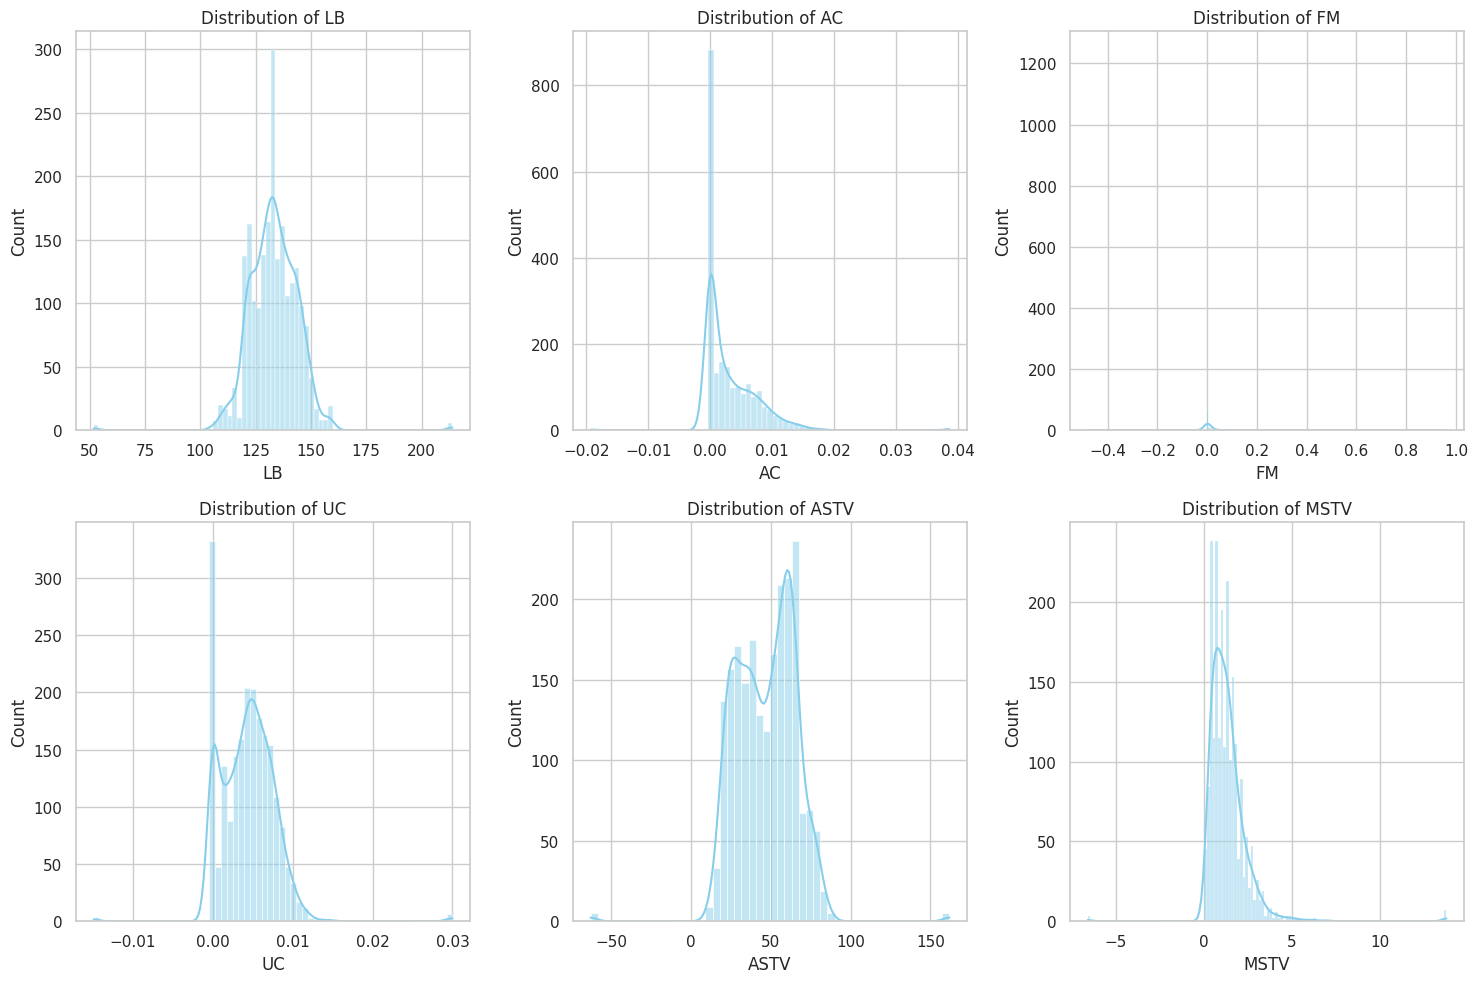

In [7]:
cols_to_plot = ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV']
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('histograms.png')

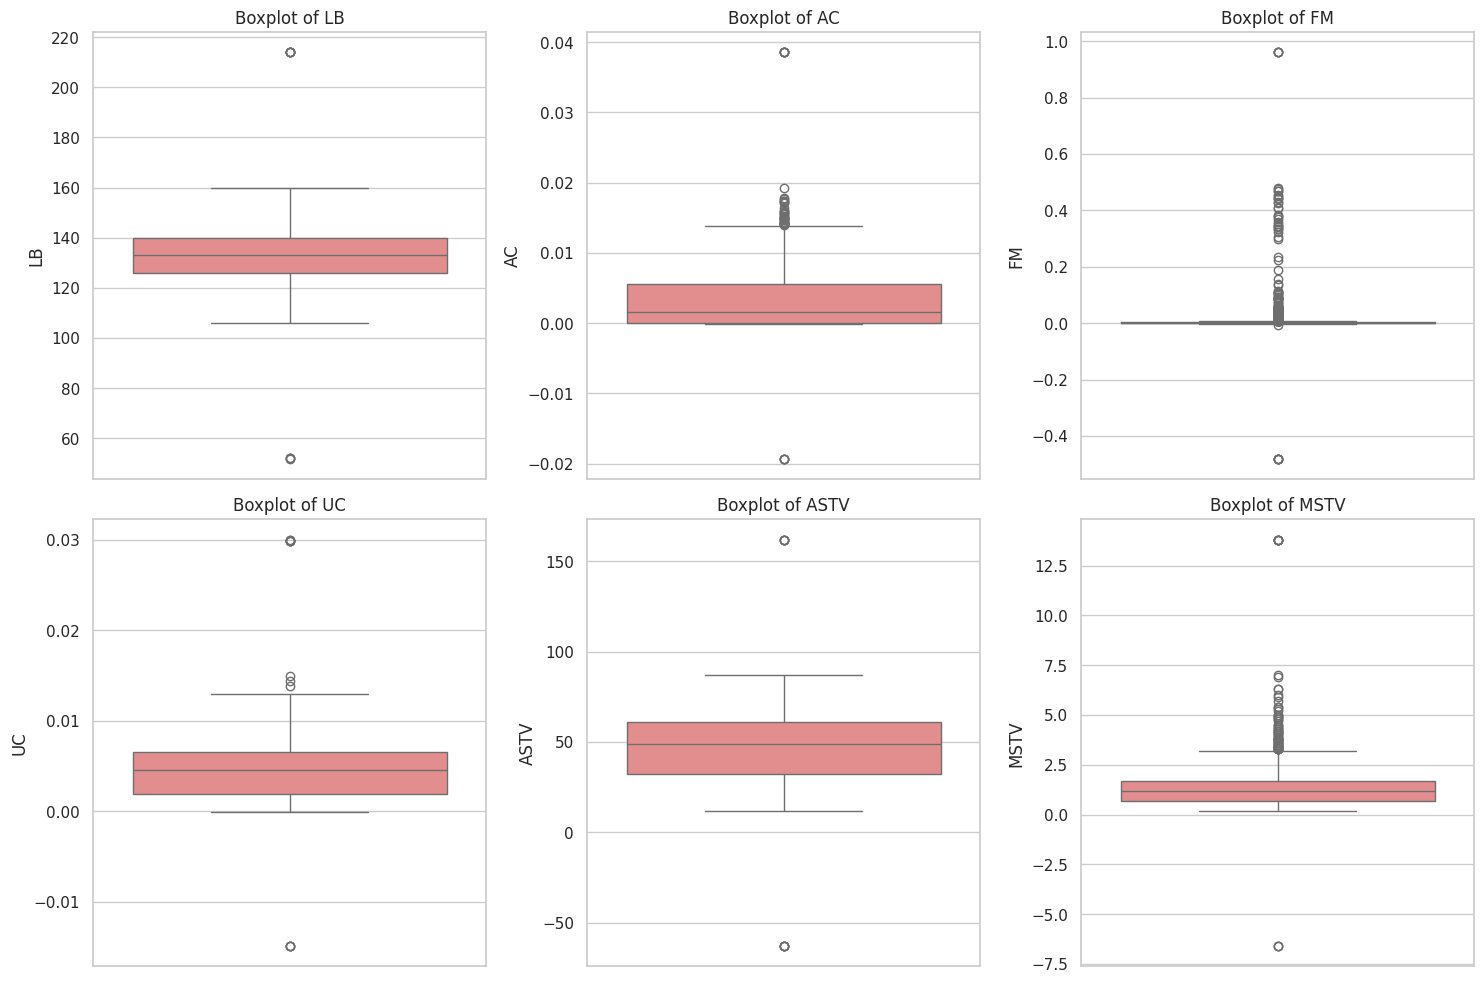

In [8]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('boxplots.png')

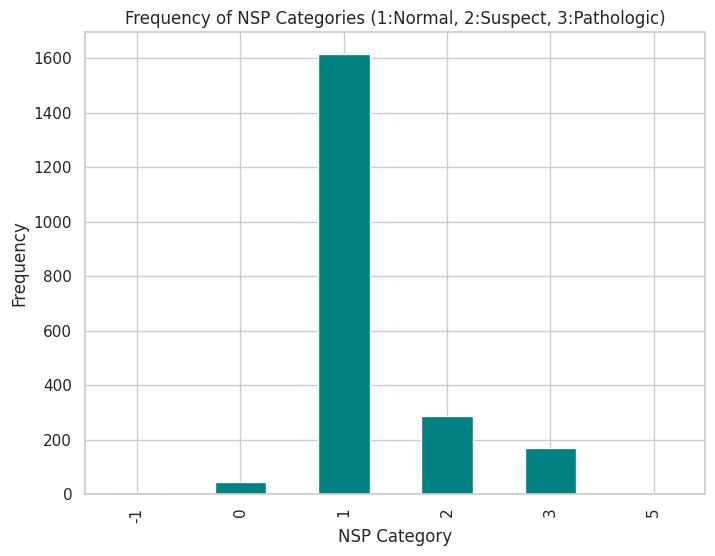

In [9]:
plt.figure(figsize=(8, 6))
df['NSP'].value_counts().sort_index().plot(kind='bar', color='teal')
plt.title('Frequency of NSP Categories (1:Normal, 2:Suspect, 3:Pathologic)')
plt.xlabel('NSP Category')
plt.ylabel('Frequency')
plt.savefig('nsp_frequency.png')

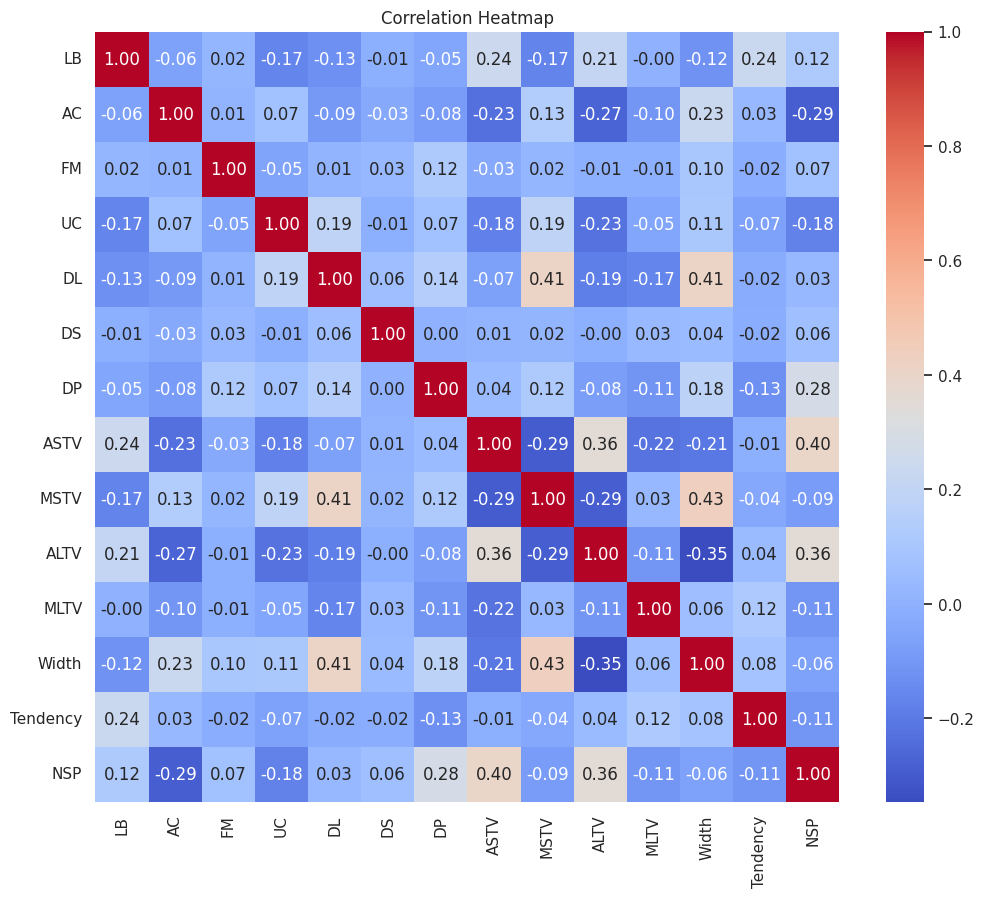

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

/tmp/ipykernel_6304/4104262615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='NSP', y='ASTV', data=df, palette='muted')


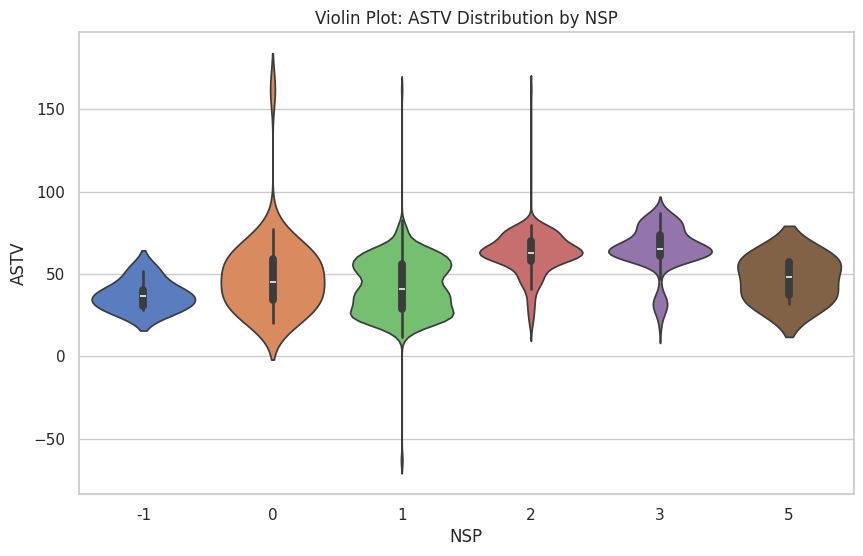

In [11]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='NSP', y='ASTV', data=df, palette='muted')
plt.title('Violin Plot: ASTV Distribution by NSP')
plt.savefig('violin_plot.png')


EDA completed. Plots saved as PNG files.


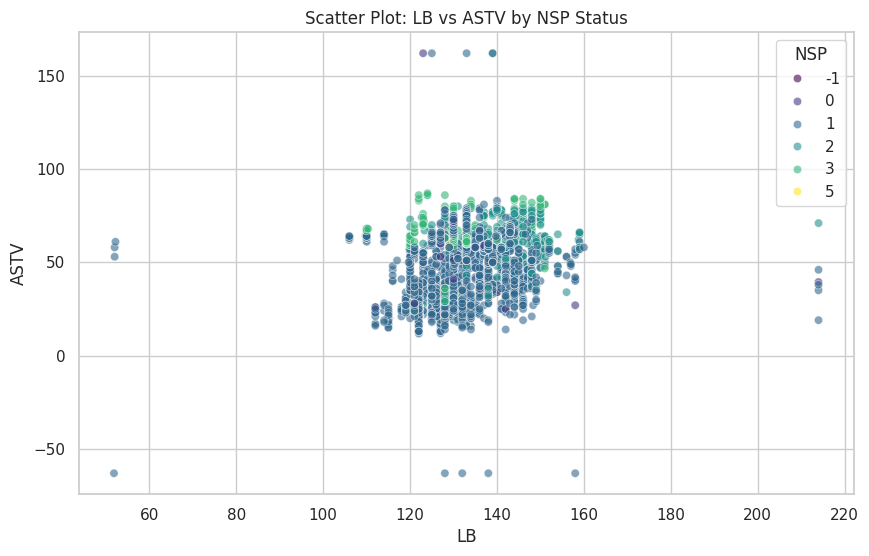

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LB', y='ASTV', hue='NSP', data=df, palette='viridis', alpha=0.6)
plt.title('Scatter Plot: LB vs ASTV by NSP Status')
plt.savefig('scatter_plot.png')

print("\nEDA completed. Plots saved as PNG files.")